<h2 style="color:#34495e;">Warm-Up DL Programming – Task 1</h2>

<hr style="border:1px solid #ddd;">

**👤 Name:** Tila Muhammad  
**🆔 Roll No:** 25i-7601  
**🎓 Class:** MS-AI  
**👨‍🏫 Instructor:** Dr. Ijaz Hussain

This report presents an exploratory data analysis (EDA) of the IMDb Movie Reviews dataset for sentiment classification. The objective is to assess dataset readiness for deep learning models.

<div style="border-left:4px solid #ff9800; background:#f0fff4; padding:10px; border-radius:10px">

### 🎬 IMDb Movie Reviews Dataset (Hugging Face)

- **Source:** HuggingFace Datasets  
- **Total Samples:** 100,000 movie reviews  

#### 📂 Data Splits
- **Training Set:** 25,000 labeled reviews  
- **Test Set:** 25,000 labeled reviews  
- **Unsupervised Set:** 50,000 unlabeled reviews  

#### 🧠 Problem Formulation
- **Input (x):** Movie review text  
- **Target (y):** Sentiment label  
  - `0` → Negative  
  - `1` → Positive
- **Features:** `text`, `label`  
- **Task Type:** Binary Text Classification (Sentiment Analysis)
</div>

#### Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from datasets import load_dataset
from collections import Counter
from statistics import mean, median

In [2]:
nltk.download("punkt")
nltk.download("punkt_tab")
sns.set_theme(style="whitegrid")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


#### Load Dataset

In [3]:
print("Loading IMDB Dataset...")
imdb = load_dataset("imdb")
print(imdb)

Loading IMDB Dataset...
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


#### Train–Validation Split

In [4]:
train_valid = imdb["train"].train_test_split(
    test_size=0.2,
    seed=42
)
train_data = train_valid["train"]
val_data   = train_valid["test"]
test_data  = imdb["test"]

In [5]:
pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Samples": [len(train_data), len(val_data), len(test_data)]
})

,Split,Samples
0,Train,20000
1,Validation,5000
2,Test,25000


#### Sample Text Examples

In [6]:
for i in range(8):
    print(f"Sample {i+1}")
    print(train_data[i]["text"][:400], "...")
    print("Label:", "Positive" if train_data[i]["label"]==1 else "Negative")
    print("-"*90)

Sample 1
Stage adaptations often have a major fault. They often come out looking like a film camera was simply placed on the stage (Such as "Night Mother"). Sidney Lumet's direction keeps the film alive, which is especially difficult since the picture offered him no real challenge. Still, it's nice to look at for what it is. The chemistry between Michael Caine and Christopher Reeve is quite brilliant. The  ...
Label: Positive
------------------------------------------------------------------------------------------
Sample 2
'The Rookie' was a wonderful movie about the second chances life holds for us and also puts an emotional thought over the audience, making them realize that your dreams can come true. If you loved 'Remember the Titans', 'The Rookie' is the movie for you!! It's the feel good movie of the year and it is the perfect movie for all ages. 'The Rookie' hits a major home run! ...
Label: Positive
-------------------------------------------------------------------------------

#### Label Distribution

In [7]:
labels = [x["label"] for x in train_data]
label_counts = Counter(labels)

pd.DataFrame.from_dict(
    label_counts, orient="index", columns=["Count"]
)

,Count
1,9994
0,10006


#### Imbalance Ratio

In [8]:
imbalance_ratio = max(label_counts.values()) / min(label_counts.values())
print("Imbalance Ratio:", imbalance_ratio)

Imbalance Ratio: 1.0012007204322593


#### Label Distribution Plot (Train Set)

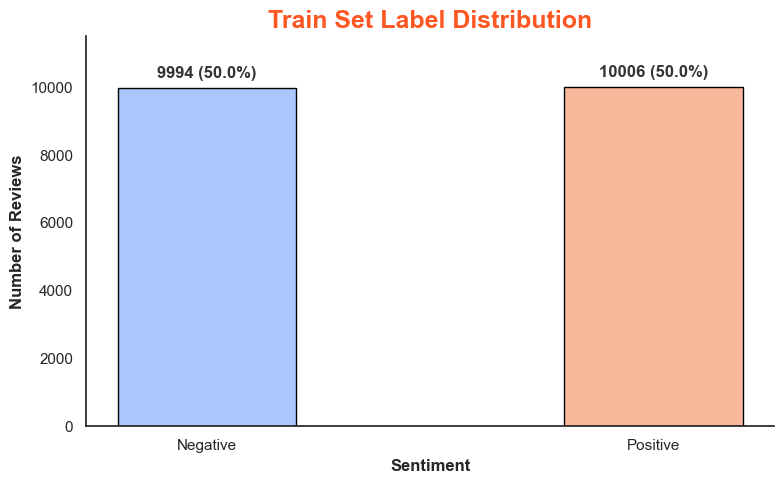

In [22]:
labels = ["Negative", "Positive"]
counts = list(label_counts.values())
total = sum(counts)
percentages = [count / total * 100 for count in counts]

plt.figure(figsize=(8,5))
sns.set_style("white")
colors = sns.color_palette("coolwarm", n_colors=len(labels))

bars = plt.bar(labels, counts, color=colors, width=0.4, edgecolor='black')

for bar, count, pct in zip(bars, counts, percentages):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + total*0.01, 
             f"{count} ({pct:.1f}%)", 
             ha='center', va='bottom', fontsize=12, fontweight='bold', color="#333")

plt.title("Train Set Label Distribution", fontsize=18, weight='bold', color="#ff5722")
plt.ylabel("Number of Reviews", fontsize=12, weight='bold')
plt.xlabel("Sentiment", fontsize=12, weight='bold')

sns.despine(top=True, right=True)

plt.ylim(0, max(counts)*1.15) 
plt.tight_layout()
plt.show()

#### Token Length Analysis

In [10]:
def token_lengths(data):
    return [
        len(nltk.word_tokenize(x["text"]))
        for x in data
    ]

train_lengths = token_lengths(train_data)

#### Text Length Statistics

In [11]:
length_stats = {
    "Min": min(train_lengths),
    "Mean": int(mean(train_lengths)),
    "Median": int(median(train_lengths)),
    "P90": int(np.percentile(train_lengths, 90)),
    "P95": int(np.percentile(train_lengths, 95)),
    "Max": max(train_lengths)
}

pd.DataFrame(length_stats, index=["Tokens"])

,Min,Mean,Median,P90,P95,Max
Tokens,11,283,210,555,722,2818


#### Token Length Distribution

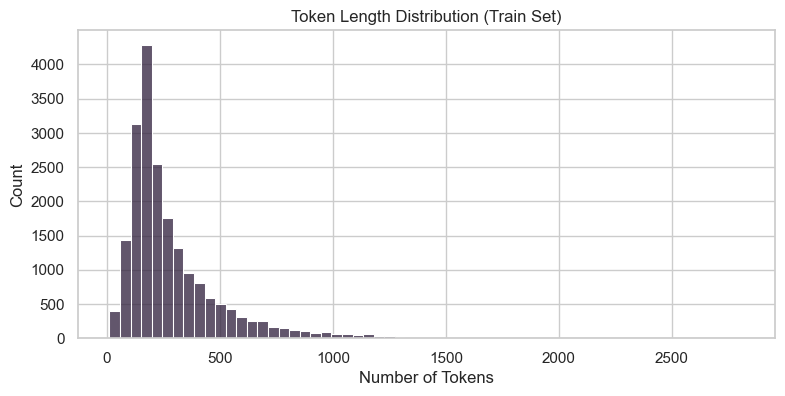

In [18]:
plt.figure(figsize=(9,4))
sns.histplot(train_lengths, bins=60)
plt.title("Token Length Distribution (Train Set)")
plt.xlabel("Number of Tokens")
plt.show()

#### Vocabulary Size (Approximate)

In [16]:
vocab = set()

for item in train_data:
    vocab.update(
        nltk.word_tokenize(item["text"].lower())
    )

print("Approximate Vocabulary Size:", len(vocab))

Approximate Vocabulary Size: 99634


#### Data Quality Checks

In [15]:
quality_report = {
    "Empty Text": sum(1 for x in train_data if x["text"].strip()==""),
    "Missing Labels": sum(1 for x in train_data if x["label"] is None),
    "Very Short Texts (<10 chars)": sum(1 for x in train_data if len(x["text"]) < 10)
}
pd.DataFrame.from_dict(quality_report, orient="index", columns=["Count"])

,Count
Empty Text,0
Missing Labels,0
Very Short Texts (<10 chars),0


#### Final Conclusion

After conducting an exploratory data analysis on the IMDb Movie Reviews dataset to assess its suitability for deep learning based sentiment classification. I found the dataset well-structured, clean, and balanced, with an imbalance ratio close to 1.0, which indicates there is no class bias.
Conversely, Token length analysis showed a right-skewed distribution, due to the majority of reviews are of moderate length, while a small number of long reviews act as outliers. However, Percentile-based statistics showed that 90% and 95% of the samples contain fewer than 555 and 722 tokens respectively, providing a clear guideline for selecting an efficient sequence length for model training.

Lastly, Data quality checks confirmed the absence of missing labels and empty text samples, further validating the dataset’s readiness for training. Based on these findings, the IMDb dataset is suitable for training deep learning models such as LSTM, GRU, and Transformer-based architectures, with appropriate truncation and padding strategies.